# Notebook 03 — Benchmark of Data Operations

## NYC Yellow Taxi Trip Data

This notebook benchmarks common database-like operations using different Python Big Data and parallel processing libraries.

The goal is to compare execution times across libraries and dataset sizes.

The benchmark uses three processed datasets:

- **Small dataset**: 100,000 rows sampled from January 2022
- **Base dataset**: cleaned January 2022
- **Large dataset**: cleaned January, February and March 2022

The libraries considered are:

- Pandas
- Dask
- Modin
- Joblib
- PySpark pandas API
- RAPIDS/cuDF, if available

The results generated here will be used in the final report to analyze performance, scalability and library suitability for different operations.

In [1]:
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import time
import os
import gc
import warnings
import platform
import subprocess
import importlib.metadata

warnings.filterwarnings("ignore")

## 1. Project paths

The benchmark uses processed Parquet files created in the previous notebooks.

The input files are stored in `data/processed`.

The benchmark outputs will be saved in `results`.

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SMALL_FILE = PROCESSED_DIR / "yellow_tripdata_2022-01_small_100k.parquet"
BASE_FILE = PROCESSED_DIR / "yellow_tripdata_2022-01_clean.parquet"
LARGE_FILE = PROCESSED_DIR / "yellow_tripdata_2022_q1_clean.parquet"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)
print("Results directory:", RESULTS_DIR)
print()
print("Small file:", SMALL_FILE)
print("Base file:", BASE_FILE)
print("Large file:", LARGE_FILE)

Project root: /Users/nunoantunes/Desktop/nyc_taxi_project
Processed directory: /Users/nunoantunes/Desktop/nyc_taxi_project/data/processed
Results directory: /Users/nunoantunes/Desktop/nyc_taxi_project/results

Small file: /Users/nunoantunes/Desktop/nyc_taxi_project/data/processed/yellow_tripdata_2022-01_small_100k.parquet
Base file: /Users/nunoantunes/Desktop/nyc_taxi_project/data/processed/yellow_tripdata_2022-01_clean.parquet
Large file: /Users/nunoantunes/Desktop/nyc_taxi_project/data/processed/yellow_tripdata_2022_q1_clean.parquet


In [3]:
required_files = [SMALL_FILE, BASE_FILE, LARGE_FILE]

for file_path in required_files:
    if file_path.exists():
        size_mb = file_path.stat().st_size / (1024 ** 2)
        print(f"Found: {file_path.name} | Size: {size_mb:.2f} MB")
    else:
        raise FileNotFoundError(f"Missing file: {file_path}")

Found: yellow_tripdata_2022-01_small_100k.parquet | Size: 2.92 MB
Found: yellow_tripdata_2022-01_clean.parquet | Size: 48.42 MB
Found: yellow_tripdata_2022_q1_clean.parquet | Size: 174.64 MB


## 2. Benchmark configuration

The same set of operations is applied to all libraries and datasets.

The operations are:

1. Read data
2. Count rows
3. Calculate mean fare amount
4. Group by payment type and calculate mean fare
5. Filter trips with distance greater than 5 miles
6. Sort trips by fare amount and return the top records
7. Join with a small location lookup table

For lazy libraries such as Dask and Spark, operations are forced to execute using actions such as `compute()`, `len()` or `head()`.

In [4]:
RUN_SMALL_DATASET = True
RUN_BASE_DATASET = True
RUN_LARGE_DATASET = True

TOP_N = 1000
DISTANCE_THRESHOLD = 5
RANDOM_STATE = 42

OPERATIONS = [
    "read_data",
    "count_rows",
    "mean_fare_amount",
    "groupby_payment_type_mean_fare",
    "filter_distance_gt_5",
    "sort_top_fares",
    "join_location_lookup"
]

operation_descriptions = {
    "read_data": "Read the Parquet file and materialize the row count.",
    "count_rows": "Count the number of rows.",
    "mean_fare_amount": "Calculate the mean value of fare_amount.",
    "groupby_payment_type_mean_fare": "Group by payment_type and calculate mean fare_amount.",
    "filter_distance_gt_5": "Filter trips with trip_distance greater than 5.",
    "sort_top_fares": "Sort by fare_amount descending and return the top records.",
    "join_location_lookup": "Join the dataset with a small lookup table using PULocationID."
}

for operation, description in operation_descriptions.items():
    print(f"{operation}: {description}")

read_data: Read the Parquet file and materialize the row count.
count_rows: Count the number of rows.
mean_fare_amount: Calculate the mean value of fare_amount.
groupby_payment_type_mean_fare: Group by payment_type and calculate mean fare_amount.
filter_distance_gt_5: Filter trips with trip_distance greater than 5.
sort_top_fares: Sort by fare_amount descending and return the top records.
join_location_lookup: Join the dataset with a small lookup table using PULocationID.


## 3. Dataset selection

The benchmark includes three dataset sizes.

This allows the analysis to compare not only library performance, but also how each library behaves as data volume increases.

In [5]:
benchmark_datasets = {}

if RUN_SMALL_DATASET:
    benchmark_datasets["taxi_small_100k"] = SMALL_FILE

if RUN_BASE_DATASET:
    benchmark_datasets["taxi_base_jan_2022"] = BASE_FILE

if RUN_LARGE_DATASET:
    benchmark_datasets["taxi_large_q1_2022"] = LARGE_FILE

print("Datasets selected for benchmark:")

for dataset_name, dataset_path in benchmark_datasets.items():
    print(f"- {dataset_name}: {dataset_path.name}")

Datasets selected for benchmark:
- taxi_small_100k: yellow_tripdata_2022-01_small_100k.parquet
- taxi_base_jan_2022: yellow_tripdata_2022-01_clean.parquet
- taxi_large_q1_2022: yellow_tripdata_2022_q1_clean.parquet


## 4. Dataset metadata

Before running the benchmark, basic metadata is collected for each dataset.

This includes:

- file path
- number of rows
- file size in MB

In [6]:
def get_parquet_row_count(path: Path) -> int:
    """
    Get the number of rows in a Parquet file without loading the full file when possible.
    """
    try:
        import pyarrow.parquet as pq
        return pq.ParquetFile(path).metadata.num_rows
    except Exception:
        return len(pd.read_parquet(path, columns=["fare_amount"]))


dataset_metadata = []

for dataset_name, dataset_path in benchmark_datasets.items():
    rows = get_parquet_row_count(dataset_path)
    size_mb = dataset_path.stat().st_size / (1024 ** 2)

    dataset_metadata.append({
        "dataset": dataset_name,
        "file": dataset_path.name,
        "path": str(dataset_path),
        "rows": rows,
        "size_mb": round(size_mb, 2)
    })

dataset_metadata_df = pd.DataFrame(dataset_metadata)
dataset_metadata_df

,dataset,file,path,rows,size_mb
0,taxi_small_100k,yellow_tripdata_2022-01_small_100k.parquet,/Users/nunoantunes/Desktop/nyc_taxi_project/da...,100000,2.92
1,taxi_base_jan_2022,yellow_tripdata_2022-01_clean.parquet,/Users/nunoantunes/Desktop/nyc_taxi_project/da...,2301788,48.42
2,taxi_large_q1_2022,yellow_tripdata_2022_q1_clean.parquet,/Users/nunoantunes/Desktop/nyc_taxi_project/da...,8453954,174.64


## 5. Create lookup table for join benchmark

To benchmark join operations, a small lookup table is created using `PULocationID`.

This simulates a common Big Data operation where a large fact table is joined with a smaller dimension table.

In [7]:
lookup_source = pd.read_parquet(BASE_FILE, columns=["PULocationID"])

unique_locations = (
    lookup_source["PULocationID"]
    .dropna()
    .astype(int)
    .drop_duplicates()
    .sort_values()
)

location_lookup = pd.DataFrame({
    "PULocationID": unique_locations,
    "location_group": unique_locations % 10
})

LOCATION_LOOKUP_FILE = PROCESSED_DIR / "location_lookup.parquet"
location_lookup.to_parquet(LOCATION_LOOKUP_FILE, index=False)

print(f"Location lookup created with {len(location_lookup)} rows.")
location_lookup.head()

Location lookup created with 253 rows.


,PULocationID,location_group
27240,1,1
594150,2,2
279385,3,3
34,4,4
26336,5,5


## 6. Execution environment

Benchmark results depend strongly on the execution environment.

For this reason, this notebook records information about:

- operating system
- Python version
- CPU configuration
- available memory
- installed library versions
- GPU availability, when applicable

This information is important because the same code may produce different execution times on another machine or cluster.

In [8]:
environment_info = {
    "operating_system": platform.system(),
    "os_version": platform.version(),
    "machine": platform.machine(),
    "processor": platform.processor(),
    "python_version": platform.python_version(),
    "cpu_count": os.cpu_count()
}

try:
    import psutil

    total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
    available_ram_gb = psutil.virtual_memory().available / (1024 ** 3)

    environment_info["total_ram_gb"] = round(total_ram_gb, 2)
    environment_info["available_ram_gb"] = round(available_ram_gb, 2)

except Exception:
    environment_info["total_ram_gb"] = "not_available"
    environment_info["available_ram_gb"] = "not_available"

environment_df = pd.DataFrame(
    list(environment_info.items()),
    columns=["property", "value"]
)

environment_df

,property,value
0,operating_system,Darwin
1,os_version,Darwin Kernel Version 24.6.0: Mon Aug 11 21:16...
2,machine,arm64
3,processor,arm
4,python_version,3.11.14
5,cpu_count,10
6,total_ram_gb,16.0
7,available_ram_gb,3.12


## 7. GPU availability

RAPIDS/cuDF requires a compatible GPU environment.

Since this notebook may be executed on a local CPU machine, GPU availability is checked separately.

If no compatible GPU is detected, the RAPIDS benchmark will be skipped and this limitation will be reported.

In [9]:
def check_nvidia_gpu():
    """
    Check whether nvidia-smi is available.
    """
    try:
        result = subprocess.run(
            ["nvidia-smi"],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )

        if result.returncode == 0:
            return True, result.stdout.split("\n")[0]
        else:
            return False, "nvidia-smi not available"

    except Exception:
        return False, "nvidia-smi not available"


gpu_available, gpu_info = check_nvidia_gpu()

print("GPU available:", gpu_available)
print("GPU info:", gpu_info)

GPU available: False
GPU info: nvidia-smi not available


## 8. Library setup

The benchmark compares several libraries.

Each library is imported and registered only if it is available in the current environment.

This avoids stopping the whole notebook when one optional library, such as RAPIDS/cuDF, is not available.

In [10]:
available_libraries = {}
import_errors = {}
library_versions = {}


def register_library(library_name, import_name=None):
    """
    Check whether a library is installed and store its version.
    """
    if import_name is None:
        import_name = library_name

    try:
        version = importlib.metadata.version(import_name)
        available_libraries[library_name] = True
        library_versions[library_name] = version
        print(f"{library_name}: available | version {version}")

    except Exception as e:
        available_libraries[library_name] = False
        library_versions[library_name] = "not_available"
        import_errors[library_name] = str(e)
        print(f"{library_name}: not available")


register_library("pandas", "pandas")
register_library("dask", "dask")
register_library("modin", "modin")
register_library("joblib", "joblib")
register_library("pyspark", "pyspark")
register_library("rapids_cudf", "cudf")

pandas: available | version 2.3.3
dask: available | version 2026.1.2
modin: available | version 0.37.1
joblib: available | version 1.5.3
pyspark: available | version 4.1.1
rapids_cudf: not available


In [12]:
# Pandas is required
import pandas as pd

# Dask
if available_libraries.get("dask", False):
    try:
        import dask.dataframe as dd
    except Exception as e:
        available_libraries["dask"] = False
        import_errors["dask"] = str(e)

# Modin
if available_libraries.get("modin", False):
    try:
        os.environ.setdefault("MODIN_ENGINE", "ray")
        import modin.pandas as mpd
    except Exception as e:
        available_libraries["modin"] = False
        import_errors["modin"] = str(e)

# Joblib
if available_libraries.get("joblib", False):
    try:
        from joblib import Parallel, delayed, cpu_count
    except Exception as e:
        available_libraries["joblib"] = False
        import_errors["joblib"] = str(e)

# PySpark pandas API
if available_libraries.get("pyspark", False):
    try:
        os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

        from pyspark.sql import SparkSession
        import pyspark.pandas as ps

        spark = (
            SparkSession.builder
            .appName("NYC Taxi Benchmark")
            .master("local[*]")
            .config("spark.sql.execution.arrow.pyspark.enabled", "true")
            .config("spark.driver.memory", "4g")
            .getOrCreate()
        )

        ps.set_option("compute.default_index_type", "distributed")
        ps.set_option("compute.ops_on_diff_frames", True)

        available_libraries["pyspark_pandas"] = True
        library_versions["pyspark_pandas"] = library_versions.get("pyspark", "unknown")

    except Exception as e:
        available_libraries["pyspark_pandas"] = False
        library_versions["pyspark_pandas"] = "not_available"
        import_errors["pyspark_pandas"] = str(e)
else:
    available_libraries["pyspark_pandas"] = False
    library_versions["pyspark_pandas"] = "not_available"

# RAPIDS/cuDF
if available_libraries.get("rapids_cudf", False):
    try:
        import cudf
    except Exception as e:
        available_libraries["rapids_cudf"] = False
        import_errors["rapids_cudf"] = str(e)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/26 17:28:50 WARN Utils: Your hostname, MacBook-Air-de-Jose.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.145 instead (on interface en0)
26/05/26 17:28:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/26 17:28:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [13]:
library_availability_df = pd.DataFrame({
    "library": list(available_libraries.keys()),
    "available": list(available_libraries.values()),
    "version": [
        library_versions.get(library, "not_available")
        for library in available_libraries.keys()
    ],
    "error": [
        import_errors.get(library, "")
        for library in available_libraries.keys()
    ]
})

library_availability_df

,library,available,version,error
0,pandas,True,2.3.3,
1,dask,True,2026.1.2,
2,modin,True,0.37.1,
3,joblib,True,1.5.3,
4,pyspark,True,4.1.1,
5,rapids_cudf,False,not_available,No package metadata was found for cudf
6,pyspark_pandas,True,4.1.1,


In [14]:
environment_path = RESULTS_DIR / "execution_environment.csv"
library_availability_path = RESULTS_DIR / "library_availability.csv"

environment_df.to_csv(environment_path, index=False)
library_availability_df.to_csv(library_availability_path, index=False)

print("Execution environment saved to:", environment_path)
print("Library availability saved to:", library_availability_path)

Execution environment saved to: /Users/nunoantunes/Desktop/nyc_taxi_project/results/execution_environment.csv
Library availability saved to: /Users/nunoantunes/Desktop/nyc_taxi_project/results/library_availability.csv


## 9. Benchmark helper functions

The following helper functions are used to measure execution time and store benchmark results in a consistent format.

Each benchmark result stores:

- dataset name
- library name
- operation name
- execution time
- execution status
- compact output summary
- error message, if any

In [15]:
benchmark_results = []


def summarize_output(output):
    """
    Create a compact textual summary of an operation output.
    This avoids storing large objects in the results table.
    """
    if isinstance(output, (int, float, str)):
        return str(output)

    if isinstance(output, pd.DataFrame):
        return f"DataFrame shape={output.shape}"

    if isinstance(output, pd.Series):
        return f"Series length={len(output)}"

    if isinstance(output, tuple):
        return str(output)

    return str(type(output))


def run_timed_operation(dataset_name, library_name, operation_name, function):
    """
    Run one benchmark operation and store the result.
    """
    gc.collect()

    start_time = time.perf_counter()

    status = "success"
    error_message = ""
    output_summary = ""

    try:
        output = function()
        output_summary = summarize_output(output)

    except Exception as e:
        status = "error"
        error_message = str(e)
        output_summary = "error"

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    benchmark_results.append({
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "dataset": dataset_name,
        "library": library_name,
        "operation": operation_name,
        "execution_time_seconds": round(elapsed_time, 6),
        "status": status,
        "output_summary": output_summary,
        "error_message": error_message
    })

    if status == "success":
        print(f"[OK] {dataset_name} | {library_name} | {operation_name}: {elapsed_time:.4f}s")
    else:
        print(f"[ERROR] {dataset_name} | {library_name} | {operation_name}: {error_message}")


print("Benchmark helper functions loaded successfully.")
print("Current number of benchmark results:", len(benchmark_results))

Benchmark helper functions loaded successfully.
Current number of benchmark results: 0


## 10. Pandas benchmark

Pandas is used as the baseline library.

It runs on a single machine and is usually very efficient for small and medium-sized datasets that fit in memory.

All other libraries will be compared against Pandas.

In [16]:
def pandas_operation(dataset_path: Path, operation: str):
    """
    Run benchmark operations using Pandas.
    """
    df = pd.read_parquet(dataset_path)

    if operation == "read_data":
        return len(df)

    if operation == "count_rows":
        return len(df)

    if operation == "mean_fare_amount":
        return float(df["fare_amount"].mean())

    if operation == "groupby_payment_type_mean_fare":
        result = df.groupby("payment_type")["fare_amount"].mean()
        return result

    if operation == "filter_distance_gt_5":
        filtered = df[df["trip_distance"] > DISTANCE_THRESHOLD]
        return len(filtered)

    if operation == "sort_top_fares":
        result = df.sort_values("fare_amount", ascending=False).head(TOP_N)
        return result.shape

    if operation == "join_location_lookup":
        joined = df.merge(location_lookup, on="PULocationID", how="left")
        return joined.shape

    raise ValueError(f"Unknown operation: {operation}")

## 11. Dask benchmark

Dask provides a pandas-like API for parallel and out-of-core data processing.

Unlike Pandas, many Dask operations are lazy.

Because of this, methods such as `.compute()` and `.head()` are used to force execution.

In [17]:
def dask_operation(dataset_path: Path, operation: str):
    """
    Run benchmark operations using Dask.
    """
    ddf = dd.read_parquet(dataset_path)

    if operation == "read_data":
        return int(ddf.shape[0].compute())

    if operation == "count_rows":
        return int(ddf.shape[0].compute())

    if operation == "mean_fare_amount":
        return float(ddf["fare_amount"].mean().compute())

    if operation == "groupby_payment_type_mean_fare":
        result = ddf.groupby("payment_type")["fare_amount"].mean().compute()
        return result

    if operation == "filter_distance_gt_5":
        filtered = ddf[ddf["trip_distance"] > DISTANCE_THRESHOLD]
        return int(filtered.shape[0].compute())

    if operation == "sort_top_fares":
        result = ddf.sort_values("fare_amount", ascending=False).head(TOP_N)
        return result.shape

    if operation == "join_location_lookup":
        lookup_dd = dd.from_pandas(location_lookup, npartitions=1)
        joined = ddf.merge(lookup_dd, on="PULocationID", how="left")
        return int(joined.shape[0].compute())

    raise ValueError(f"Unknown operation: {operation}")

## 12. Modin benchmark

Modin provides a pandas-compatible API and distributes many operations across the available CPU cores.

It is useful when the goal is to keep Pandas-like syntax while attempting to improve performance on larger datasets.

In [18]:
def force_modin_execution(obj):
    """
    Force Modin objects to execute and convert them to Pandas when possible.
    """
    if hasattr(obj, "_to_pandas"):
        return obj._to_pandas()

    return obj


def modin_operation(dataset_path: Path, operation: str):
    """
    Run benchmark operations using Modin.
    """
    df = mpd.read_parquet(dataset_path)

    if operation == "read_data":
        return len(df)

    if operation == "count_rows":
        return len(df)

    if operation == "mean_fare_amount":
        return float(df["fare_amount"].mean())

    if operation == "groupby_payment_type_mean_fare":
        result = df.groupby("payment_type")["fare_amount"].mean()
        return force_modin_execution(result)

    if operation == "filter_distance_gt_5":
        filtered = df[df["trip_distance"] > DISTANCE_THRESHOLD]
        return len(filtered)

    if operation == "sort_top_fares":
        result = df.sort_values("fare_amount", ascending=False).head(TOP_N)
        result = force_modin_execution(result)
        return result.shape

    if operation == "join_location_lookup":
        lookup_modin = mpd.DataFrame(location_lookup)
        joined = df.merge(lookup_modin, on="PULocationID", how="left")
        return len(joined)

    raise ValueError(f"Unknown operation: {operation}")

## 13. Joblib benchmark

Joblib is different from Pandas, Dask and Modin.

It is not a DataFrame library.

Instead, it allows manual parallelization of Python functions.

In this benchmark, the dataset is loaded with Pandas, divided into partitions, and then processed in parallel using Joblib.

This approach gives more control but also requires more manual code.

In [19]:
N_JOBS = max(1, min(4, os.cpu_count() or 1))
N_PARTITIONS = N_JOBS * 2

print("N_JOBS:", N_JOBS)
print("N_PARTITIONS:", N_PARTITIONS)

N_JOBS: 4
N_PARTITIONS: 8


In [20]:
def split_dataframe(df: pd.DataFrame, n_partitions: int):
    """
    Split a Pandas DataFrame into several smaller partitions.
    """
    partitions = np.array_split(df, n_partitions)
    return [part for part in partitions if len(part) > 0]


def part_len(part):
    return len(part)


def part_sum_count(part, column):
    return part[column].sum(), part[column].count()


def part_groupby_sum_count(part):
    return part.groupby("payment_type")["fare_amount"].agg(["sum", "count"])


def part_filter_count(part):
    return len(part[part["trip_distance"] > DISTANCE_THRESHOLD])


def part_top_sort(part):
    return part.sort_values("fare_amount", ascending=False).head(TOP_N)


def part_join_count(part, lookup):
    joined = part.merge(lookup, on="PULocationID", how="left")
    return len(joined)


def joblib_operation(dataset_path: Path, operation: str):
    """
    Run benchmark operations using Joblib with manual Pandas partitioning.
    """
    df = pd.read_parquet(dataset_path)

    if operation == "read_data":
        return len(df)

    partitions = split_dataframe(df, N_PARTITIONS)

    if operation == "count_rows":
        counts = Parallel(n_jobs=N_JOBS)(
            delayed(part_len)(part) for part in partitions
        )
        return int(sum(counts))

    if operation == "mean_fare_amount":
        partial_results = Parallel(n_jobs=N_JOBS)(
            delayed(part_sum_count)(part, "fare_amount") for part in partitions
        )

        total_sum = sum(item[0] for item in partial_results)
        total_count = sum(item[1] for item in partial_results)

        return float(total_sum / total_count)

    if operation == "groupby_payment_type_mean_fare":
        partial_results = Parallel(n_jobs=N_JOBS)(
            delayed(part_groupby_sum_count)(part) for part in partitions
        )

        combined = pd.concat(partial_results).groupby(level=0).sum()
        combined["mean_fare_amount"] = combined["sum"] / combined["count"]

        return combined["mean_fare_amount"]

    if operation == "filter_distance_gt_5":
        counts = Parallel(n_jobs=N_JOBS)(
            delayed(part_filter_count)(part) for part in partitions
        )
        return int(sum(counts))

    if operation == "sort_top_fares":
        partial_top = Parallel(n_jobs=N_JOBS)(
            delayed(part_top_sort)(part) for part in partitions
        )

        result = (
            pd.concat(partial_top)
            .sort_values("fare_amount", ascending=False)
            .head(TOP_N)
        )

        return result.shape

    if operation == "join_location_lookup":
        counts = Parallel(n_jobs=N_JOBS)(
            delayed(part_join_count)(part, location_lookup) for part in partitions
        )
        return int(sum(counts))

    raise ValueError(f"Unknown operation: {operation}")

## 14. PySpark pandas API benchmark

The PySpark pandas API provides a pandas-like interface on top of Apache Spark.

This framework can scale to larger datasets and distributed environments, but it may have extra overhead on smaller local datasets because Spark needs to create and manage execution plans.

In [21]:
def pyspark_pandas_operation(dataset_path: Path, operation: str):
    """
    Run benchmark operations using PySpark pandas API.
    """
    psdf = ps.read_parquet(str(dataset_path))

    if operation == "read_data":
        return int(len(psdf))

    if operation == "count_rows":
        return int(len(psdf))

    if operation == "mean_fare_amount":
        return float(psdf["fare_amount"].mean())

    if operation == "groupby_payment_type_mean_fare":
        result = psdf.groupby("payment_type")["fare_amount"].mean()
        return result.to_pandas()

    if operation == "filter_distance_gt_5":
        filtered = psdf[psdf["trip_distance"] > DISTANCE_THRESHOLD]
        return int(len(filtered))

    if operation == "sort_top_fares":
        result = psdf.sort_values("fare_amount", ascending=False).head(TOP_N)
        return result.shape

    if operation == "join_location_lookup":
        lookup_ps = ps.from_pandas(location_lookup)
        joined = psdf.merge(lookup_ps, on="PULocationID", how="left")
        return int(len(joined))

    raise ValueError(f"Unknown operation: {operation}")

## 16. Register benchmark runners

Only libraries that were successfully imported are included in the benchmark.

This prevents optional libraries from interrupting the complete experiment.

In [23]:
benchmark_runners = {}

if available_libraries.get("pandas", False):
    benchmark_runners["pandas"] = pandas_operation

if available_libraries.get("dask", False):
    benchmark_runners["dask"] = dask_operation

if available_libraries.get("modin", False):
    benchmark_runners["modin"] = modin_operation

if available_libraries.get("joblib", False):
    benchmark_runners["joblib"] = joblib_operation

if available_libraries.get("pyspark_pandas", False):
    benchmark_runners["pyspark_pandas"] = pyspark_pandas_operation

if available_libraries.get("rapids_cudf", False):
    benchmark_runners["rapids_cudf"] = rapids_cudf_operation

print("Libraries selected for benchmark:")

for library_name in benchmark_runners:
    print("-", library_name)

if len(benchmark_runners) == 0:
    raise RuntimeError("No benchmark libraries available.")

Libraries selected for benchmark:
- pandas
- dask
- modin
- joblib
- pyspark_pandas


## 17. Run benchmark

The following cell runs every selected operation for every available library and dataset.

The results are stored progressively in a CSV file, so partial results are not lost if one operation fails.

This step may take longer because it includes the larger Q1 2022 dataset.

In [24]:
partial_results_path = RESULTS_DIR / "benchmark_results_partial.csv"

for dataset_name, dataset_path in benchmark_datasets.items():
    print()
    print("=" * 80)
    print(f"Dataset: {dataset_name}")
    print("=" * 80)

    for library_name, runner in benchmark_runners.items():
        print()
        print("-" * 80)
        print(f"Library: {library_name}")
        print("-" * 80)

        for operation in OPERATIONS:
            run_timed_operation(
                dataset_name=dataset_name,
                library_name=library_name,
                operation_name=operation,
                function=lambda runner=runner, dataset_path=dataset_path, operation=operation: runner(dataset_path, operation)
            )

            pd.DataFrame(benchmark_results).to_csv(partial_results_path, index=False)

print()
print("Benchmark completed.")


Dataset: taxi_small_100k

--------------------------------------------------------------------------------
Library: pandas
--------------------------------------------------------------------------------
[OK] taxi_small_100k | pandas | read_data: 0.0115s
[OK] taxi_small_100k | pandas | count_rows: 0.0047s
[OK] taxi_small_100k | pandas | mean_fare_amount: 0.0046s
[OK] taxi_small_100k | pandas | groupby_payment_type_mean_fare: 0.0051s
[OK] taxi_small_100k | pandas | filter_distance_gt_5: 0.0042s
[OK] taxi_small_100k | pandas | sort_top_fares: 0.0121s
[OK] taxi_small_100k | pandas | join_location_lookup: 0.0070s

--------------------------------------------------------------------------------
Library: dask
--------------------------------------------------------------------------------
[OK] taxi_small_100k | dask | read_data: 0.1313s
[OK] taxi_small_100k | dask | count_rows: 0.0042s
[OK] taxi_small_100k | dask | mean_fare_amount: 0.0061s
[OK] taxi_small_100k | dask | groupby_payment_type

2026-05-26 17:34:25,641	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-26 17:34:29,483	INFO worker.py:2012 -- Started a local Ray instance.
2026-05-26 17:34:31,565	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


[OK] taxi_small_100k | modin | read_data: 7.3602s
[OK] taxi_small_100k | modin | count_rows: 0.0951s
[OK] taxi_small_100k | modin | mean_fare_amount: 0.1236s
[OK] taxi_small_100k | modin | groupby_payment_type_mean_fare: 0.1358s
[OK] taxi_small_100k | modin | filter_distance_gt_5: 0.1170s
[OK] taxi_small_100k | modin | sort_top_fares: 0.1721s
[OK] taxi_small_100k | modin | join_location_lookup: 0.1296s

--------------------------------------------------------------------------------
Library: joblib
--------------------------------------------------------------------------------
[OK] taxi_small_100k | joblib | read_data: 0.0075s
[OK] taxi_small_100k | joblib | count_rows: 0.5917s
[OK] taxi_small_100k | joblib | mean_fare_amount: 0.1681s
[OK] taxi_small_100k | joblib | groupby_payment_type_mean_fare: 0.1559s
[OK] taxi_small_100k | joblib | filter_distance_gt_5: 0.1509s
[OK] taxi_small_100k | joblib | sort_top_fares: 0.1611s
[OK] taxi_small_100k | joblib | join_location_lookup: 0.1635s

-

(raylet) Spilled 2074 MiB, 24 objects, write throughput 476 MiB/s. Set RAY_verbose_spill_logs=0 to disable this message.
(raylet) Spilled 4514 MiB, 83 objects, write throughput 595 MiB/s.


[OK] taxi_large_q1_2022 | modin | sort_top_fares: 12.6365s


(raylet) Spilled 9465 MiB, 150 objects, write throughput 683 MiB/s.


[OK] taxi_large_q1_2022 | modin | join_location_lookup: 10.3646s

--------------------------------------------------------------------------------
Library: joblib
--------------------------------------------------------------------------------
[OK] taxi_large_q1_2022 | joblib | read_data: 0.6434s
[OK] taxi_large_q1_2022 | joblib | count_rows: 4.5410s
[OK] taxi_large_q1_2022 | joblib | mean_fare_amount: 3.6577s
[OK] taxi_large_q1_2022 | joblib | groupby_payment_type_mean_fare: 4.0181s
[OK] taxi_large_q1_2022 | joblib | filter_distance_gt_5: 1.9461s
[OK] taxi_large_q1_2022 | joblib | sort_top_fares: 3.9690s
[OK] taxi_large_q1_2022 | joblib | join_location_lookup: 3.1504s

--------------------------------------------------------------------------------
Library: pyspark_pandas
--------------------------------------------------------------------------------
[OK] taxi_large_q1_2022 | pyspark_pandas | read_data: 0.1221s
[OK] taxi_large_q1_2022 | pyspark_pandas | count_rows: 0.1113s
[OK] taxi_

## 18. Benchmark results

The raw benchmark results are converted into a DataFrame and inspected.

Each row represents one operation executed by one library on one dataset.

In [25]:
results_df = pd.DataFrame(benchmark_results)

results_df

,timestamp,dataset,library,operation,execution_time_seconds,status,output_summary,error_message
0,2026-05-26 17:34:23,taxi_small_100k,pandas,read_data,0.011469,success,100000,
1,2026-05-26 17:34:24,taxi_small_100k,pandas,count_rows,0.004743,success,100000,
2,2026-05-26 17:34:24,taxi_small_100k,pandas,mean_fare_amount,0.004632,success,12.6159065,
3,2026-05-26 17:34:24,taxi_small_100k,pandas,groupby_payment_type_mean_fare,0.005066,success,Series length=4,
4,2026-05-26 17:34:24,taxi_small_100k,pandas,filter_distance_gt_5,0.004151,success,14228,
...,...,...,...,...,...,...,...,...
100,2026-05-26 17:35:57,taxi_large_q1_2022,pyspark_pandas,mean_fare_amount,0.118306,success,13.197587826949892,
101,2026-05-26 17:35:58,taxi_large_q1_2022,pyspark_pandas,groupby_payment_type_mean_fare,0.173623,success,Series length=5,
102,2026-05-26 17:35:58,taxi_large_q1_2022,pyspark_pandas,filter_distance_gt_5,0.128789,success,1263345,
103,2026-05-26 17:35:58,taxi_large_q1_2022,pyspark_pandas,sort_top_fares,0.165242,success,"(1000, 23)",


In [26]:
errors_df = results_df[results_df["status"] == "error"]

if len(errors_df) > 0:
    display(errors_df[["dataset", "library", "operation", "error_message"]])
else:
    print("No benchmark errors.")

No benchmark errors.


## 19. Execution time pivot table

The following table shows execution time in seconds.

Rows represent dataset and operation.

Columns represent libraries.

This format is useful for the report because it follows the assignment requirement: operations as rows, libraries as columns and execution time as cell values.

In [27]:
successful_results = results_df[results_df["status"] == "success"].copy()

pivot_results = successful_results.pivot_table(
    index=["dataset", "operation"],
    columns="library",
    values="execution_time_seconds",
    aggfunc="mean"
)

pivot_results

library                                                dask    joblib  \
dataset            operation                                            
taxi_base_jan_2022 count_rows                      0.004357  0.559601   
                   filter_distance_gt_5            0.023478  0.931849   
                   groupby_payment_type_mean_fare  0.060042  0.552695   
                   join_location_lookup            0.055936  1.042848   
                   mean_fare_amount                0.017943  0.645099   
                   read_data                       0.005200  0.139963   
                   sort_top_fares                  0.546137  1.338881   
taxi_large_q1_2022 count_rows                      0.004729  4.540987   
                   filter_distance_gt_5            0.074342  1.946111   
                   groupby_payment_type_mean_fare  0.207179  4.018067   
                   join_location_lookup            0.192659  3.150378   
                   mean_fare_amount                0.071978  3.657711   
                   read_data                       0.010390  0.643420   
                   sort_top_fares                  2.787081  3.968982   
taxi_small_100k    count_rows                      0.004243  0.591737   
                   filter_distance_gt_5            0.007715  0.150944   
                   groupby_payment_type_mean_fare  0.011450  0.155946   
                   join_location_lookup            0.012316  0.163522   
                   mean_fare_amount                0.006052  0.168069   
                   read_data                       0.131334  0.007512   
                   sort_top_fares                  0.020141  0.161129   

library                                                modin    pandas  \
dataset            operation                                             
taxi_base_jan_2022 count_rows                       0.723250  0.056151   
                   filter_distance_gt_5             1.047423  0.074325   
                   groupby_payment_type_mean_fare   0.626396  0.080738   
                   join_location_lookup             1.019285  0.146839   
                   mean_fare_amount                 0.740087  0.054489   
                   read_data                        0.854940  0.156707   
                   sort_top_fares                   2.272088  0.323546   
taxi_large_q1_2022 count_rows                       0.761312  0.287394   
                   filter_distance_gt_5             4.009351  0.459054   
                   groupby_payment_type_mean_fare   1.039764  0.328238   
                   join_location_lookup            10.364612  0.889130   
                   mean_fare_amount                 0.585386  0.266241   
                   read_data                        0.704112  0.608047   
                   sort_top_fares                  12.636466  1.822960   
taxi_small_100k    count_rows                       0.095115  0.004743   
                   filter_distance_gt_5             0.117037  0.004151   
                   groupby_payment_type_mean_fare   0.135753  0.005066   
                   join_location_lookup             0.129556  0.006956   
                   mean_fare_amount                 0.123649  0.004632   
                   read_data                        7.360247  0.011469   
                   sort_top_fares                   0.172084  0.012090   

library                                            pyspark_pandas  
dataset            operation                                       
taxi_base_jan_2022 count_rows                            0.112013  
                   filter_distance_gt_5                  0.155956  
                   groupby_payment_type_mean_fare        0.187802  
                   join_location_lookup                  0.241363  
                   mean_fare_amount                      0.128047  
                   read_data                             0.149108  
                   sort_top_fares                        0.177369  
taxi_

## 20. Speedup compared with Pandas

For each operation, speedup is calculated as:

`Pandas execution time / Library execution time`

Values above 1 mean that the library was faster than Pandas.

Values below 1 mean that the library was slower than Pandas.

In [28]:
speedup_rows = []

for dataset_name in successful_results["dataset"].unique():
    for operation in successful_results["operation"].unique():

        subset = successful_results[
            (successful_results["dataset"] == dataset_name) &
            (successful_results["operation"] == operation)
        ]

        pandas_time_values = subset.loc[
            subset["library"] == "pandas",
            "execution_time_seconds"
        ].values

        if len(pandas_time_values) == 0:
            continue

        pandas_time = pandas_time_values[0]

        for _, row in subset.iterrows():
            if row["execution_time_seconds"] > 0:
                speedup = pandas_time / row["execution_time_seconds"]
            else:
                speedup = np.nan

            speedup_rows.append({
                "dataset": dataset_name,
                "operation": operation,
                "library": row["library"],
                "execution_time_seconds": row["execution_time_seconds"],
                "speedup_vs_pandas": round(speedup, 4)
            })

speedup_df = pd.DataFrame(speedup_rows)

speedup_df

,dataset,operation,library,execution_time_seconds,speedup_vs_pandas
0,taxi_small_100k,read_data,pandas,0.011469,1.0000
1,taxi_small_100k,read_data,dask,0.131334,0.0873
2,taxi_small_100k,read_data,modin,7.360247,0.0016
3,taxi_small_100k,read_data,joblib,0.007512,1.5268
4,taxi_small_100k,read_data,pyspark_pandas,1.497170,0.0077
...,...,...,...,...,...
100,taxi_large_q1_2022,join_location_lookup,pandas,0.889130,1.0000
101,taxi_large_q1_2022,join_location_lookup,dask,0.192659,4.6150
102,taxi_large_q1_2022,join_location_lookup,modin,10.364612,0.0858
103,taxi_large_q1_2022,join_location_lookup,joblib,3.150378,0.2822


In [29]:
speedup_pivot = speedup_df.pivot_table(
    index=["dataset", "operation"],
    columns="library",
    values="speedup_vs_pandas",
    aggfunc="mean"
)

speedup_pivot

library                                               dask  joblib   modin  \
dataset            operation                                                 
taxi_base_jan_2022 count_rows                      12.8875  0.1003  0.0776   
                   filter_distance_gt_5             3.1657  0.0798  0.0710   
                   groupby_payment_type_mean_fare   1.3447  0.1461  0.1289   
                   join_location_lookup             2.6251  0.1408  0.1441   
                   mean_fare_amount                 3.0368  0.0845  0.0736   
                   read_data                       30.1360  1.1196  0.1833   
                   sort_top_fares                   0.5924  0.2417  0.1424   
taxi_large_q1_2022 count_rows                      60.7727  0.0633  0.3775   
                   filter_distance_gt_5             6.1749  0.2359  0.1145   
                   groupby_payment_type_mean_fare   1.5843  0.0817  0.3157   
                   join_location_lookup             4.6150  0.2822  0.0858   
                   mean_fare_amount                 3.6989  0.0728  0.4548   
                   read_data                       58.5223  0.9450  0.8636   
                   sort_top_fares                   0.6541  0.4593  0.1443   
taxi_small_100k    count_rows                       1.1178  0.0080  0.0499   
                   filter_distance_gt_5             0.5380  0.0275  0.0355   
                   groupby_payment_type_mean_fare   0.4424  0.0325  0.0373   
                   join_location_lookup             0.5648  0.0425  0.0537   
                   mean_fare_amount                 0.7654  0.0276  0.0375   
                   read_data                        0.0873  1.5268  0.0016   
                   sort_top_fares                   0.6003  0.0750  0.0703   

library                                            pandas  pyspark_pandas  
dataset            operation                                               
taxi_base_jan_2022 count_rows                         1.0          0.5013  
                   filter_distance_gt_5               1.0          0.4766  
                   groupby_payment_type_mean_fare     1.0          0.4299  
                   join_location_lookup               1.0          0.6084  
                   mean_fare_amount                   1.0          0.4255  
                   read_data                          1.0          1.0510  
                   sort_top_fares                     1.0          1.8241  
taxi_large_q1_2022 count_rows                         1.0          2.5828  
                   filter_distance_gt_5               1.0          3.5644  
                   groupby_payment_type_mean_fare     1.0          1.8905  
                   join_location_lookup               1.0          4.2580  
                   mean_fare_amount                   1.0          2.2504  
                   read_data                          1.0          4.9808  
                   sort_top_fares                     1.0         11.0321  
taxi_small_100k    count_rows                         1.0          0.0258  
                   filter_distance_gt_5               1.0          0.0183  
                   groupby_payment_type_mean_fare     1.0          0.0156  
                   join_location_lookup               1.0          0.0250  
                   mean_fare_amount                   1.0          0.0106  
                   read_data                          1.0          0.0077  
                   sort_top_fares                     1.0          0.0578

## 21. Summary by library

This table gives an overall view of the average execution time per library and dataset.

It helps identify which libraries had the best global performance across the tested operations.

In [30]:
summary_by_library = (
    successful_results
    .groupby(["dataset", "library"])["execution_time_seconds"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
    .sort_values(["dataset", "mean"])
)

summary_by_library

,dataset,library,count,mean,median,min,max
0,taxi_base_jan_2022,dask,7,0.101870,0.023478,0.004357,0.546137
3,taxi_base_jan_2022,pandas,7,0.127542,0.080738,0.054489,0.323546
4,taxi_base_jan_2022,pyspark_pandas,7,0.164523,0.155956,0.112013,0.241363
1,taxi_base_jan_2022,joblib,7,0.744419,0.645099,0.139963,1.338881
2,taxi_base_jan_2022,modin,7,1.040496,0.854940,0.626396,2.272088
9,taxi_large_q1_2022,pyspark_pandas,7,0.146875,0.128789,0.111272,0.208815
5,taxi_large_q1_2022,dask,7,0.478337,0.074342,0.004729,2.787081
8,taxi_large_q1_2022,pandas,7,0.665866,0.459054,0.266241,1.822960
6,taxi_large_q1_2022,joblib,7,3.132237,3.657711,0.643420,4.540987
7,taxi_large_q1_2022,modin,7,4.300143,1.039764,0.585386,12.636466


## 22. Best library per operation

This table identifies the fastest library for each dataset and operation.

This is useful because the best library may change depending on the operation being executed.

In [31]:
best_by_operation = (
    successful_results
    .sort_values("execution_time_seconds")
    .groupby(["dataset", "operation"])
    .first()
    .reset_index()
)

best_by_operation = best_by_operation[
    ["dataset", "operation", "library", "execution_time_seconds", "output_summary"]
]

best_by_operation

,dataset,operation,library,execution_time_seconds,output_summary
0,taxi_base_jan_2022,count_rows,dask,0.004357,2301788
1,taxi_base_jan_2022,filter_distance_gt_5,dask,0.023478,328061
2,taxi_base_jan_2022,groupby_payment_type_mean_fare,dask,0.060042,Series length=5
3,taxi_base_jan_2022,join_location_lookup,dask,0.055936,2301788
4,taxi_base_jan_2022,mean_fare_amount,dask,0.017943,12.63893388096558
5,taxi_base_jan_2022,read_data,dask,0.005200,2301788
6,taxi_base_jan_2022,sort_top_fares,pyspark_pandas,0.177369,"(1000, 23)"
7,taxi_large_q1_2022,count_rows,dask,0.004729,8453954
8,taxi_large_q1_2022,filter_distance_gt_5,dask,0.074342,1263345
9,taxi_large_q1_2022,groupby_payment_type_mean_fare,pyspark_pandas,0.173623,Series length=5


## 23. Save benchmark tables

The benchmark tables are saved to CSV files.

These files will be used later in the final report and for visual analysis.

In [32]:
results_long_path = RESULTS_DIR / "benchmark_results_long.csv"
pivot_results_path = RESULTS_DIR / "benchmark_results_pivot.csv"
speedup_path = RESULTS_DIR / "benchmark_speedup_vs_pandas.csv"
summary_path = RESULTS_DIR / "benchmark_summary_by_library.csv"
best_path = RESULTS_DIR / "benchmark_best_by_operation.csv"
dataset_metadata_path = RESULTS_DIR / "dataset_metadata.csv"

results_df.to_csv(results_long_path, index=False)
pivot_results.to_csv(pivot_results_path)
speedup_df.to_csv(speedup_path, index=False)
summary_by_library.to_csv(summary_path, index=False)
best_by_operation.to_csv(best_path, index=False)
dataset_metadata_df.to_csv(dataset_metadata_path, index=False)

print("Saved files:")
print(results_long_path)
print(pivot_results_path)
print(speedup_path)
print(summary_path)
print(best_path)
print(dataset_metadata_path)

Saved files:
/Users/nunoantunes/Desktop/nyc_taxi_project/results/benchmark_results_long.csv
/Users/nunoantunes/Desktop/nyc_taxi_project/results/benchmark_results_pivot.csv
/Users/nunoantunes/Desktop/nyc_taxi_project/results/benchmark_speedup_vs_pandas.csv
/Users/nunoantunes/Desktop/nyc_taxi_project/results/benchmark_summary_by_library.csv
/Users/nunoantunes/Desktop/nyc_taxi_project/results/benchmark_best_by_operation.csv
/Users/nunoantunes/Desktop/nyc_taxi_project/results/dataset_metadata.csv


## 24. Visual comparison

The next cells create simple plots comparing execution time across libraries.

Lower execution time means better performance.

A logarithmic scale is used because some operations can be much slower than others, especially when a library has high initialization or distributed execution overhead.

In [33]:
import matplotlib.pyplot as plt

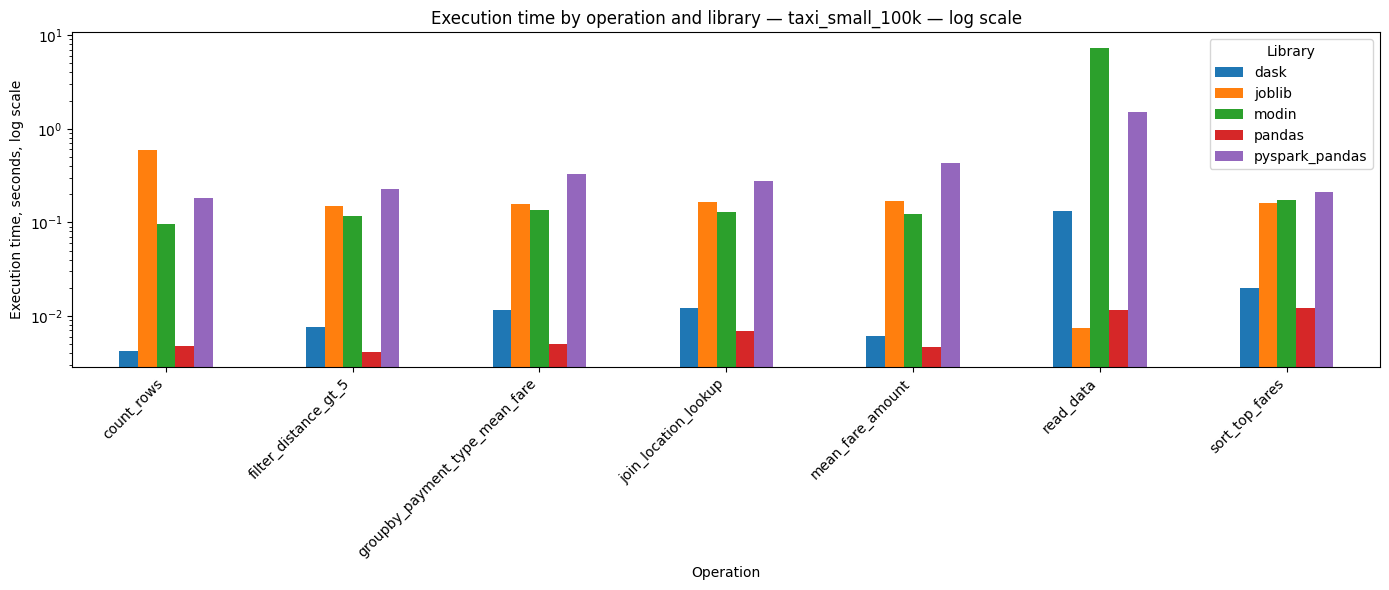

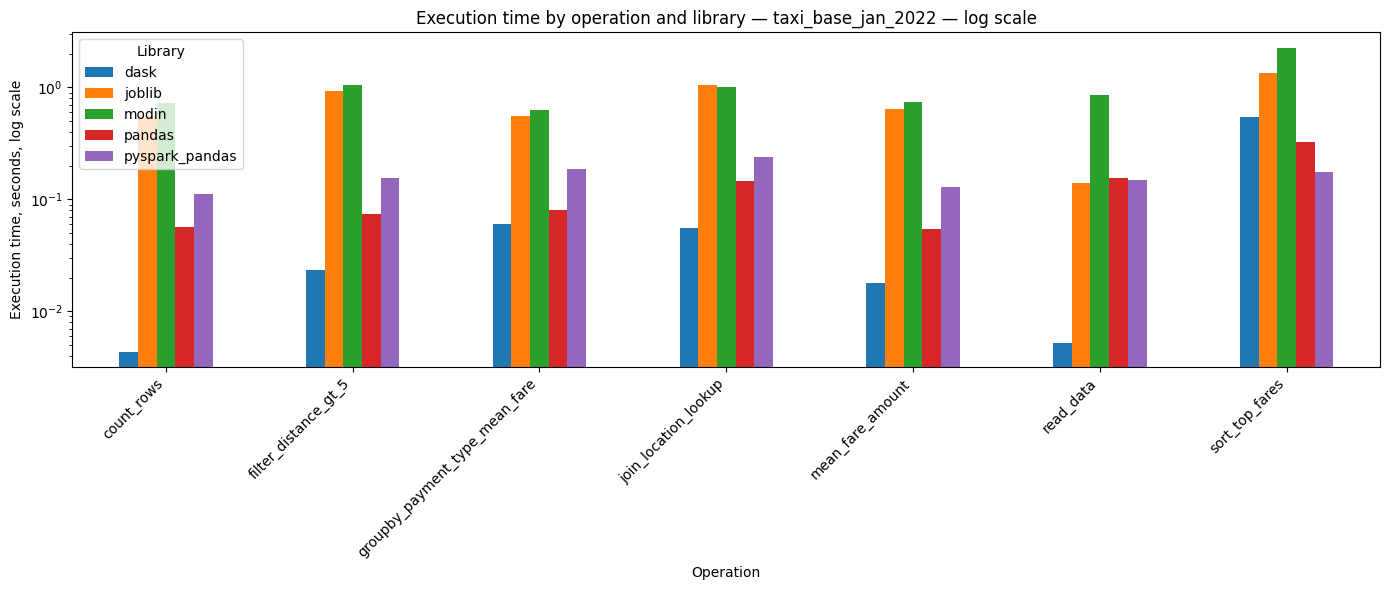

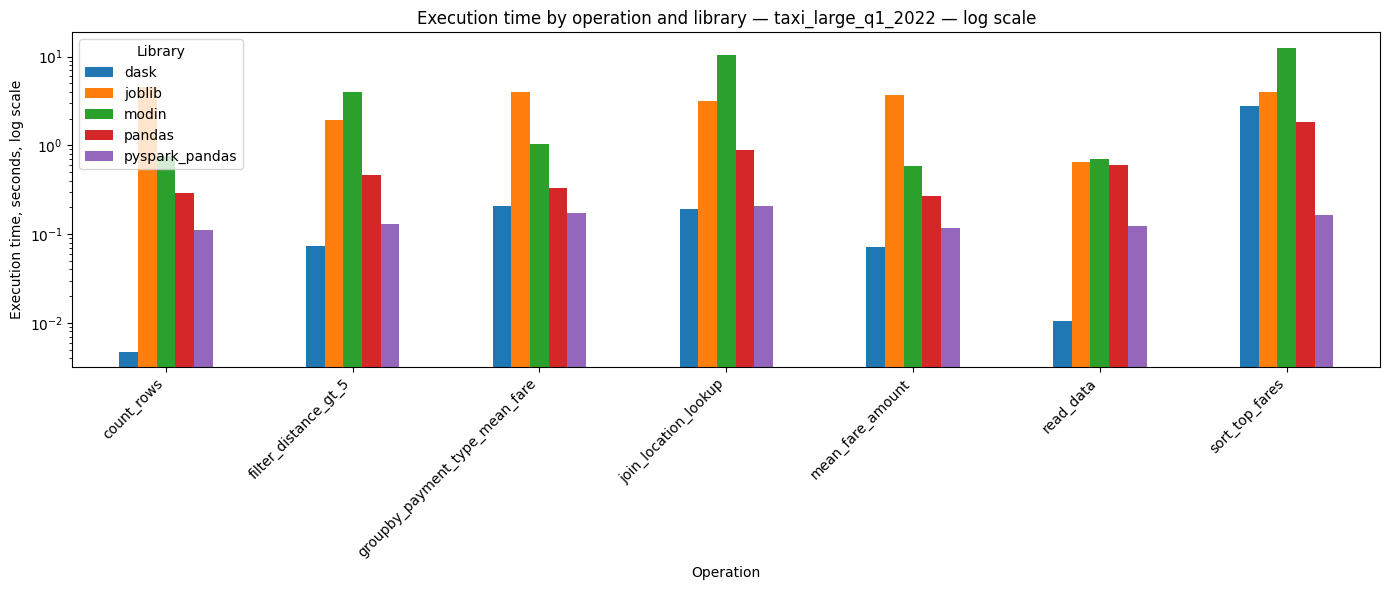

In [34]:
for dataset_name in successful_results["dataset"].unique():
    plot_data = successful_results[
        successful_results["dataset"] == dataset_name
    ]

    plot_pivot = plot_data.pivot_table(
        index="operation",
        columns="library",
        values="execution_time_seconds",
        aggfunc="mean"
    )

    ax = plot_pivot.plot(
        kind="bar",
        figsize=(14, 6),
        logy=True
    )

    ax.set_title(f"Execution time by operation and library — {dataset_name} — log scale")
    ax.set_xlabel("Operation")
    ax.set_ylabel("Execution time, seconds, log scale")
    ax.legend(title="Library")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 25. Speedup visualization

The following chart compares each library against Pandas.

A value above 1 means that the library was faster than Pandas.

A value below 1 means that the library was slower than Pandas.

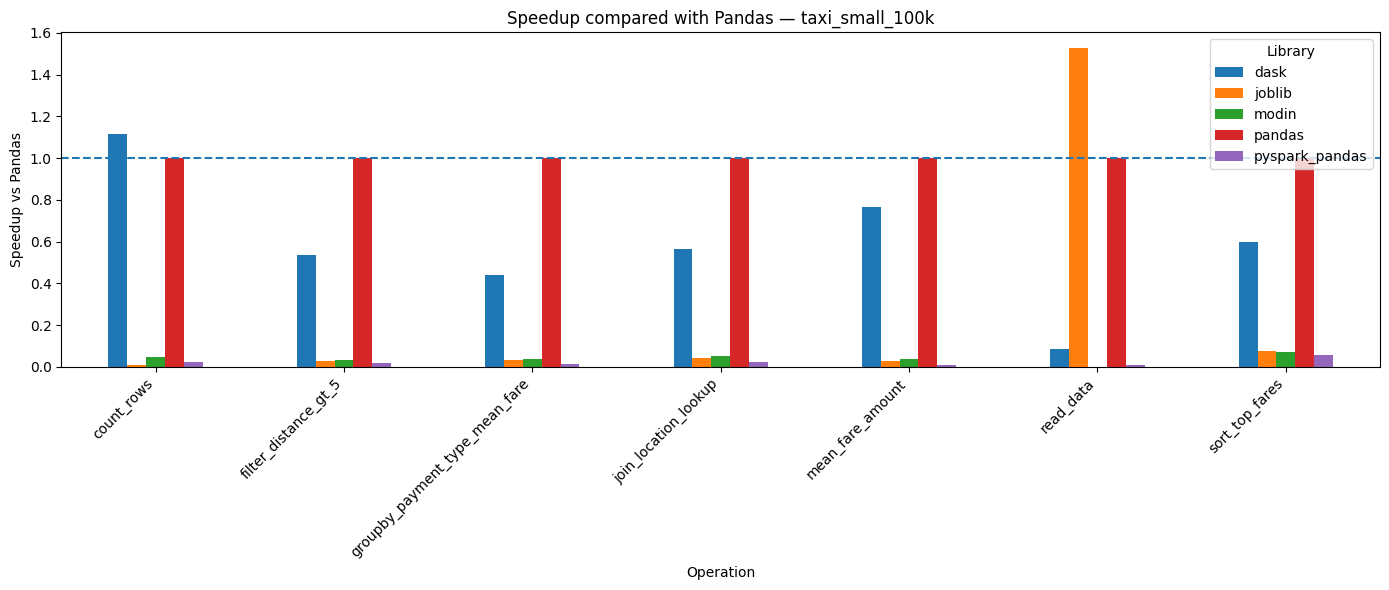

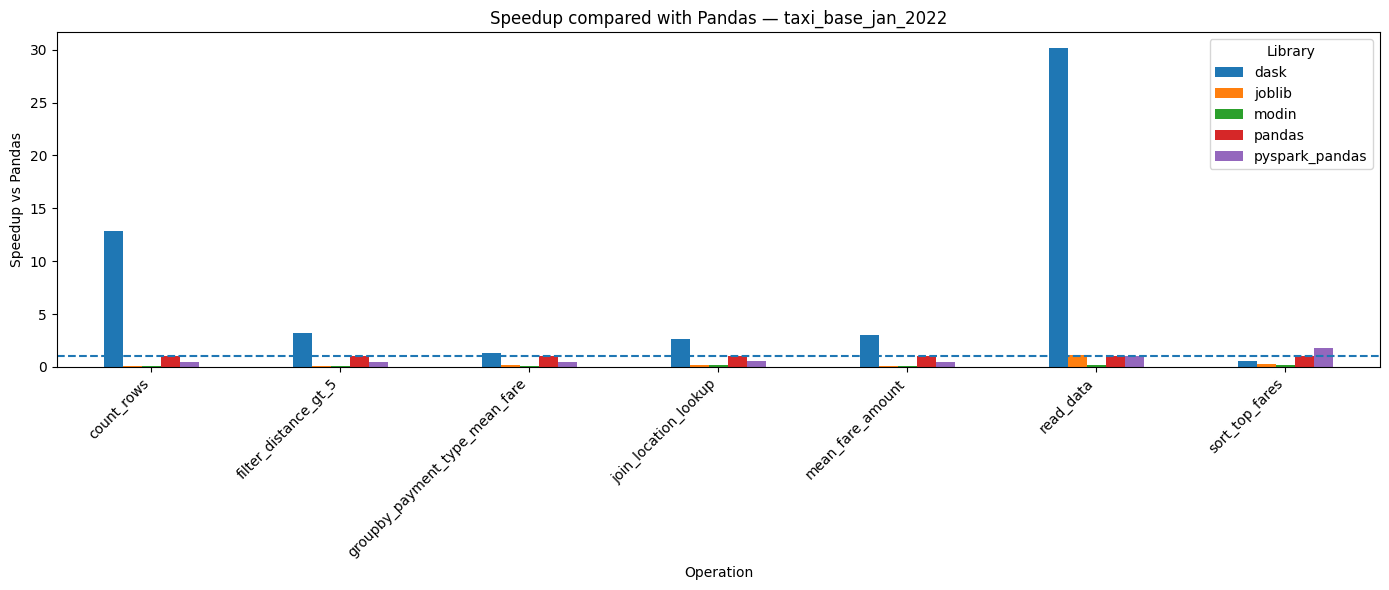

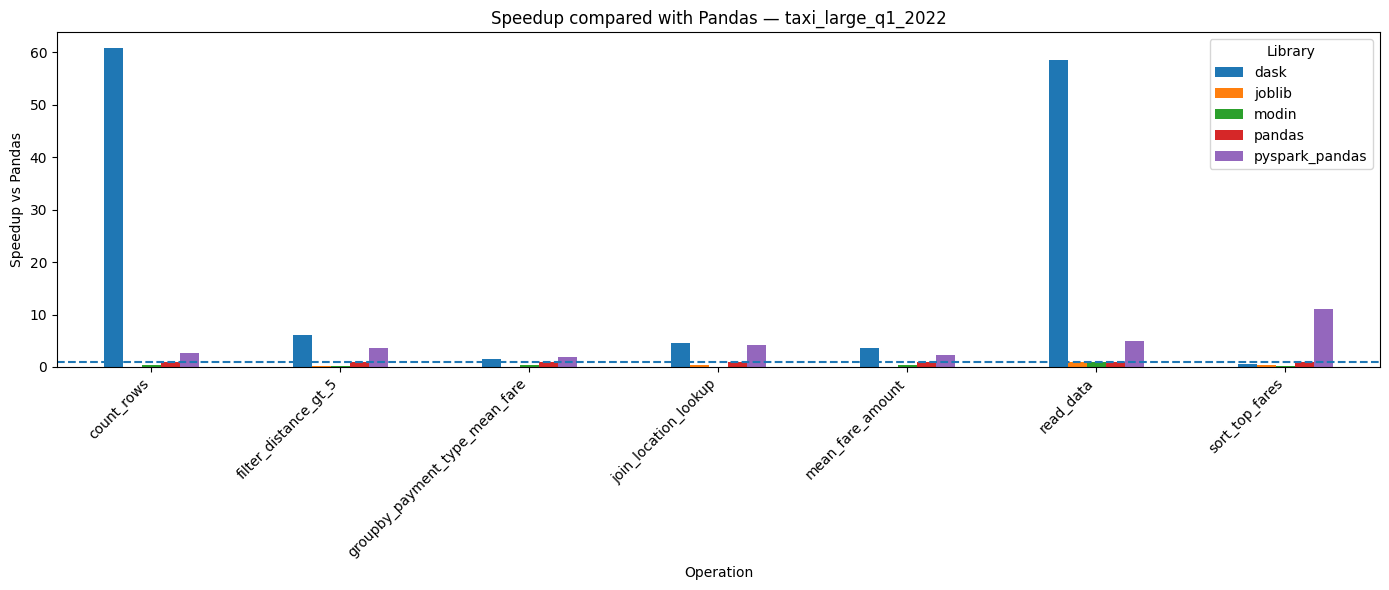

In [36]:
for dataset_name in speedup_df["dataset"].unique():
    plot_data = speedup_df[
        speedup_df["dataset"] == dataset_name
    ]

    plot_pivot = plot_data.pivot_table(
        index="operation",
        columns="library",
        values="speedup_vs_pandas",
        aggfunc="mean"
    )

    ax = plot_pivot.plot(
        kind="bar",
        figsize=(14, 6)
    )

    ax.axhline(1.0, linestyle="--")
    ax.set_title(f"Speedup compared with Pandas — {dataset_name}")
    ax.set_xlabel("Operation")
    ax.set_ylabel("Speedup vs Pandas")
    ax.legend(title="Library")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 26. Optional profiling with cProfile

The assignment mentions that profiling tools can be used to analyze performance bottlenecks.

The following example profiles one Pandas operation using `cProfile`.


In [37]:
import cProfile
import pstats
from io import StringIO

In [38]:
def profile_pandas_groupby():
    df = pd.read_parquet(SMALL_FILE)
    result = df.groupby("payment_type")["fare_amount"].mean()
    return result


profiler = cProfile.Profile()
profiler.enable()

profile_pandas_groupby()

profiler.disable()

stream = StringIO()
stats = pstats.Stats(profiler, stream=stream).sort_stats("cumulative")
stats.print_stats(15)

print(stream.getvalue())

         1963 function calls (1791 primitive calls) in 0.036 seconds

   Ordered by: cumulative time
   List reduced from 402 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.036    0.018 /opt/homebrew/Caskroom/miniforge/base/envs/bigdata-ml/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3665(run_code)
        2    0.000    0.000    0.036    0.018 {built-in method builtins.exec}
        1    0.000    0.000    0.036    0.036 /var/folders/j_/3ct18bbj7h3btd2py8q_f_k00000gp/T/ipykernel_11052/568625052.py:1(profile_pandas_groupby)
        1    0.000    0.000    0.032    0.032 /opt/homebrew/Caskroom/miniforge/base/envs/bigdata-ml/lib/python3.11/site-packages/pandas/io/parquet.py:500(read_parquet)
        1    0.000    0.000    0.032    0.032 /opt/homebrew/Caskroom/miniforge/base/envs/bigdata-ml/lib/python3.11/site-packages/pandas/io/parquet.py:240(read)
        1    0.000    0.000    0.022  

## 27. Discussion notes

The benchmark results can be discussed using the following points:

1. Pandas is usually strong on small datasets because it has low overhead.
2. Dask may become more useful as data size increases, especially for larger-than-memory datasets.
3. Modin can speed up some Pandas-like operations, but it may have overhead depending on the operation and engine.
4. Joblib is useful for custom parallel operations, but it requires manual partitioning and aggregation logic.
5. PySpark pandas API can scale well, but it has initialization and execution overhead on small datasets.
6. RAPIDS/cuDF can be very fast when a compatible GPU is available, but it depends on CUDA and hardware support.
7. Lazy execution frameworks require explicit actions to measure real execution time.
8. The fastest library may differ depending on the operation, dataset size and hardware.
9. The large dataset allows the project to analyze scalability more clearly than using only a single month.

In [39]:
print("Notebook 03 completed successfully.")
print("Benchmark results saved in:", RESULTS_DIR)

Notebook 03 completed successfully.
Benchmark results saved in: /Users/nunoantunes/Desktop/nyc_taxi_project/results


26/05/26 18:41:33 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 121933 ms exceeds timeout 120000 ms
26/05/26 18:41:33 WARN SparkContext: Killing executors is not supported by current scheduler.
26/05/26 18:41:36 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:81)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:674)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1363)
	at o